In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

import umap

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except Exception:
    HDBSCAN_AVAILABLE = False


# ------------------------------------------------------------
# Config
# ------------------------------------------------------------

@dataclass(slots=True)
class PhaseFConfig:
    project_root: Path

    # ---- Input files ----
    embeddings_csv: Path
    master_csv: Path
    feature_csv: Path | None = None

    # ---- Output folder ----
    output_dir: Path | None = None

    # ---- Dimensionality reduction ----
    embedding_prefix_candidates: tuple[str, ...] = ("emb_", "embed_", "embedding_", "z_", "latent_")
    pca_components_for_clustering: int = 20
    umap_n_neighbors: int = 25
    umap_min_dist: float = 0.15
    umap_metric: str = "euclidean"
    random_state: int = 42

    # ---- Clustering ----
    hdbscan_min_cluster_size: int = 35
    hdbscan_min_samples: int | None = 10
    kmeans_k: int = 6
    gmm_k: int = 6
    hierarchical_k: int = 6

    # ---- Stability analysis ----
    low_energy_quantile: float = 0.10  # lowest 10% delta-energy treated as highly favorable

    @property
    def outdir(self) -> Path:
        if self.output_dir is not None:
            return self.output_dir
        return self.project_root / "outputs" / "motif_discovery"


PROJECT_ROOT = Path.cwd().resolve().parent

CONFIG = PhaseFConfig(
    project_root=PROJECT_ROOT,
    embeddings_csv=PROJECT_ROOT / "outputs" / "graph_embeddings" / "embeddings" / "structure_embeddings.csv",
    master_csv=PROJECT_ROOT / "outputs" / "dataset_master.csv",
    feature_csv=PROJECT_ROOT / "outputs" / "structural_features" / "structure_features.csv",
)

CONFIG.outdir.mkdir(parents=True, exist_ok=True)

print("Phase F output directory:", CONFIG.outdir)
print("HDBSCAN available:", HDBSCAN_AVAILABLE)

Phase F output directory: D:\masters_project\outputs\motif_discovery
HDBSCAN available: True


In [2]:
# ------------------------------------------------------------
# Shared utilities
# ------------------------------------------------------------

NON_EMBEDDING_COLUMNS = {
    "structure_id",
    "relative_cif_path",
    "energy",
    "delta_energy",
    "lower_rotation",
    "displacement",
    "upper_rotation",
    "cluster_label",
    "cluster_confidence",
    "motif_name",
}


def save_csv(df: pd.DataFrame, path: Path) -> pd.DataFrame:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return df


def pick_embedding_columns(df: pd.DataFrame, prefix_candidates: tuple[str, ...]) -> list[str]:
    candidates = []

    for col in df.columns:
        col_lower = col.lower()
        if col in NON_EMBEDDING_COLUMNS:
            continue
        if any(col_lower.startswith(prefix) for prefix in prefix_candidates):
            candidates.append(col)

    if candidates:
        return candidates

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in NON_EMBEDDING_COLUMNS]

    if not numeric_cols:
        raise ValueError("No embedding columns detected in embeddings CSV.")

    return numeric_cols


def load_phase_f_input(config: PhaseFConfig) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame | None, list[str]]:
    df_emb = pd.read_csv(config.embeddings_csv)
    df_master = pd.read_csv(config.master_csv)

    if "structure_id" not in df_emb.columns:
        raise ValueError("Embeddings CSV must contain 'structure_id'.")
    if "structure_id" not in df_master.columns:
        raise ValueError("dataset_master.csv must contain 'structure_id'.")

    df_feat = None
    if config.feature_csv is not None and config.feature_csv.exists():
        df_feat = pd.read_csv(config.feature_csv)

    embedding_cols = pick_embedding_columns(df_emb, config.embedding_prefix_candidates)

    df = df_emb.merge(
        df_master,
        on="structure_id",
        how="left",
        suffixes=("", "_master"),
        validate="one_to_one",
    )

    if df_feat is not None and "structure_id" in df_feat.columns:
        keep_cols = [c for c in df_feat.columns if c != "relative_cif_path"]
        df = df.merge(
            df_feat[keep_cols],
            on="structure_id",
            how="left",
            suffixes=("", "_feat"),
            validate="one_to_one",
        )

    missing_energy = int(df["energy"].isna().sum()) if "energy" in df.columns else -1
    missing_delta = int(df["delta_energy"].isna().sum()) if "delta_energy" in df.columns else -1

    print(f"Rows loaded                 : {len(df)}")
    print(f"Detected embedding columns  : {len(embedding_cols)}")
    print(f"Missing energy rows         : {missing_energy}")
    print(f"Missing delta energy rows   : {missing_delta}")

    return df, df_master, df_feat, embedding_cols


def build_embedding_matrix(df: pd.DataFrame, embedding_cols: list[str]) -> np.ndarray:
    X = df[embedding_cols].to_numpy(dtype=float)
    if np.isnan(X).any():
        raise ValueError("Embedding matrix contains NaN values. Clean embeddings first.")
    return X


def zscore_matrix(X: np.ndarray) -> np.ndarray:
    scaler = StandardScaler()
    return scaler.fit_transform(X)


def safe_silhouette(X: np.ndarray, labels: np.ndarray) -> float | None:
    unique = set(labels)
    if -1 in unique:
        unique.remove(-1)
    if len(unique) < 2:
        return None

    mask = labels != -1
    if mask.sum() < 3:
        return None

    return float(silhouette_score(X[mask], labels[mask]))


def assign_motif_names(summary_df: pd.DataFrame) -> pd.DataFrame:
    """
    Simple rule-based scientific labels.
    You can manually refine these later after structure inspection.
    """
    df = summary_df.copy()

    names = []
    for _, row in df.iterrows():
        disp = row.get("displacement_mean", np.nan)
        lower_std = row.get("lower_rotation_std", np.nan)
        upper_std = row.get("upper_rotation_std", np.nan)
        inter = row.get("interlayer_dist_mean_mean", np.nan)
        dE = row.get("delta_energy_mean", np.nan)

        if pd.notna(inter) and inter < df["interlayer_dist_mean_mean"].median():
            compactness = "compact"
        else:
            compactness = "loose"

        if pd.notna(disp) and disp < df["displacement_mean"].median():
            alignment = "aligned"
        else:
            alignment = "shifted"

        rotation_spread = np.nanmean([lower_std, upper_std])
        if pd.notna(rotation_spread) and rotation_spread > np.nanmedian(
            np.nanmean([df["lower_rotation_std"], df["upper_rotation_std"]], axis=0)
        ):
            twist = "twisted"
        else:
            twist = "ordered"

        if pd.notna(dE) and dE <= df["delta_energy_mean"].quantile(0.25):
            stability = "stable"
        elif pd.notna(dE) and dE >= df["delta_energy_mean"].quantile(0.75):
            stability = "unstable"
        else:
            stability = "moderate"

        names.append(f"{alignment} {compactness} {twist} stacking ({stability})")

    df["motif_name"] = names
    return df

In [3]:
df_all, df_master, df_feat, EMBEDDING_COLS = load_phase_f_input(CONFIG)
X = build_embedding_matrix(df_all, EMBEDDING_COLS)
X_scaled = zscore_matrix(X)

print("Embedding matrix shape:", X.shape)
df_all.head()

Rows loaded                 : 2916
Detected embedding columns  : 128
Missing energy rows         : 0
Missing delta energy rows   : 0
Embedding matrix shape: (2916, 128)


,structure_id,relative_cif_path,lower_rotation,displacement,upper_rotation,energy,delta_energy,emb_000,emb_001,emb_002,...,nn_min,nn_max,lower_nn_mean,lower_nn_std,lower_nn_min,lower_nn_max,upper_nn_mean,upper_nn_std,upper_nn_min,upper_nn_max
0,L0_D0_U0,r0/t0/t0_0.cif,0.0,0.0,0.0,-936.509583,0.13021,0.073159,0.141754,0.016134,...,0.977309,2.003689,1.134992,0.166349,0.977309,2.003689,1.118772,0.128105,0.977336,1.447277
1,L0_D0_U100,r0/t0/t0_100.cif,0.0,0.0,100.0,-936.201538,0.43826,-0.018456,1.128705,1.116602,...,0.977156,1.993357,1.135027,0.165855,0.977488,1.993357,1.118810,0.127971,0.977156,1.446371
2,L0_D0_U120,r0/t0/t0_120.cif,0.0,0.0,120.0,-936.242065,0.39772,-0.548361,1.584229,0.988826,...,0.977049,1.989993,1.135063,0.165559,0.977481,1.989993,1.118725,0.128255,0.977049,1.444283
3,L0_D0_U140,r0/t0/t0_140.cif,0.0,0.0,140.0,-936.156982,0.48284,-0.250084,0.888609,-0.177643,...,0.977482,2.013701,1.135251,0.167179,0.977482,2.013701,1.118680,0.128171,0.977948,1.444940
4,L0_D0_U160,r0/t0/t0_160.cif,0.0,0.0,160.0,-936.079590,0.56023,-0.080722,1.491669,-0.357859,...,0.977586,2.011914,1.135184,0.167162,0.977586,2.011914,1.118596,0.128099,0.977693,1.445462


In [4]:
# ------------------------------------------------------------
# Task 26 — Perform dimensionality reduction
# ------------------------------------------------------------

def run_dimensionality_reduction(
    df: pd.DataFrame,
    X_scaled: np.ndarray,
    config: PhaseFConfig,
) -> tuple[pd.DataFrame, dict[str, object]]:
    reducers: dict[str, object] = {}

    # PCA baseline
    pca_2d = PCA(n_components=2, random_state=config.random_state)
    pca_coords = pca_2d.fit_transform(X_scaled)
    reducers["pca_2d"] = pca_2d

    # UMAP preferred
    umap_2d = umap.UMAP(
        n_components=2,
        n_neighbors=config.umap_n_neighbors,
        min_dist=config.umap_min_dist,
        metric=config.umap_metric,
        random_state=config.random_state,
    )
    umap_coords = umap_2d.fit_transform(X_scaled)
    reducers["umap_2d"] = umap_2d

    # Optional t-SNE comparison
    tsne_2d = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=config.random_state,
    )
    tsne_coords = tsne_2d.fit_transform(X_scaled)
    reducers["tsne_2d"] = tsne_2d

    df_2d = df.copy()
    df_2d["pca_1"] = pca_coords[:, 0]
    df_2d["pca_2"] = pca_coords[:, 1]
    df_2d["umap_1"] = umap_coords[:, 0]
    df_2d["umap_2"] = umap_coords[:, 1]
    df_2d["tsne_1"] = tsne_coords[:, 0]
    df_2d["tsne_2"] = tsne_coords[:, 1]

    # Save the Phase F required deliverable
    embedding_2d_cols = [
        "structure_id",
        "relative_cif_path",
        "lower_rotation",
        "displacement",
        "upper_rotation",
        "energy",
        "delta_energy",
        "pca_1",
        "pca_2",
        "umap_1",
        "umap_2",
        "tsne_1",
        "tsne_2",
    ]
    embedding_2d_cols = [c for c in embedding_2d_cols if c in df_2d.columns]
    save_csv(df_2d[embedding_2d_cols], CONFIG.outdir / "embedding_2d.csv")

    return df_2d, reducers


df_phasef, reducers = run_dimensionality_reduction(df_all, X_scaled, CONFIG)
print("Saved:", CONFIG.outdir / "embedding_2d.csv")
df_phasef.head()

d:\masters_project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: D:\masters_project\outputs\motif_discovery\embedding_2d.csv


,structure_id,relative_cif_path,lower_rotation,displacement,upper_rotation,energy,delta_energy,emb_000,emb_001,emb_002,...,upper_nn_mean,upper_nn_std,upper_nn_min,upper_nn_max,pca_1,pca_2,umap_1,umap_2,tsne_1,tsne_2
0,L0_D0_U0,r0/t0/t0_0.cif,0.0,0.0,0.0,-936.509583,0.13021,0.073159,0.141754,0.016134,...,1.118772,0.128105,0.977336,1.447277,2.698780,-2.145542,13.232353,-9.693111,16.256012,18.173557
1,L0_D0_U100,r0/t0/t0_100.cif,0.0,0.0,100.0,-936.201538,0.43826,-0.018456,1.128705,1.116602,...,1.118810,0.127971,0.977156,1.446371,2.613275,-1.342387,11.643525,-9.549086,33.514286,17.762970
2,L0_D0_U120,r0/t0/t0_120.cif,0.0,0.0,120.0,-936.242065,0.39772,-0.548361,1.584229,0.988826,...,1.118725,0.128255,0.977049,1.444283,4.023746,-2.281294,11.926418,-9.504131,28.649391,20.207617
3,L0_D0_U140,r0/t0/t0_140.cif,0.0,0.0,140.0,-936.156982,0.48284,-0.250084,0.888609,-0.177643,...,1.118680,0.128171,0.977948,1.444940,2.047858,-4.149553,12.978029,-9.060637,15.751867,13.407825
4,L0_D0_U160,r0/t0/t0_160.cif,0.0,0.0,160.0,-936.079590,0.56023,-0.080722,1.491669,-0.357859,...,1.118596,0.128099,0.977693,1.445462,-0.147532,-2.799350,14.367900,-8.496241,-14.410838,7.230876


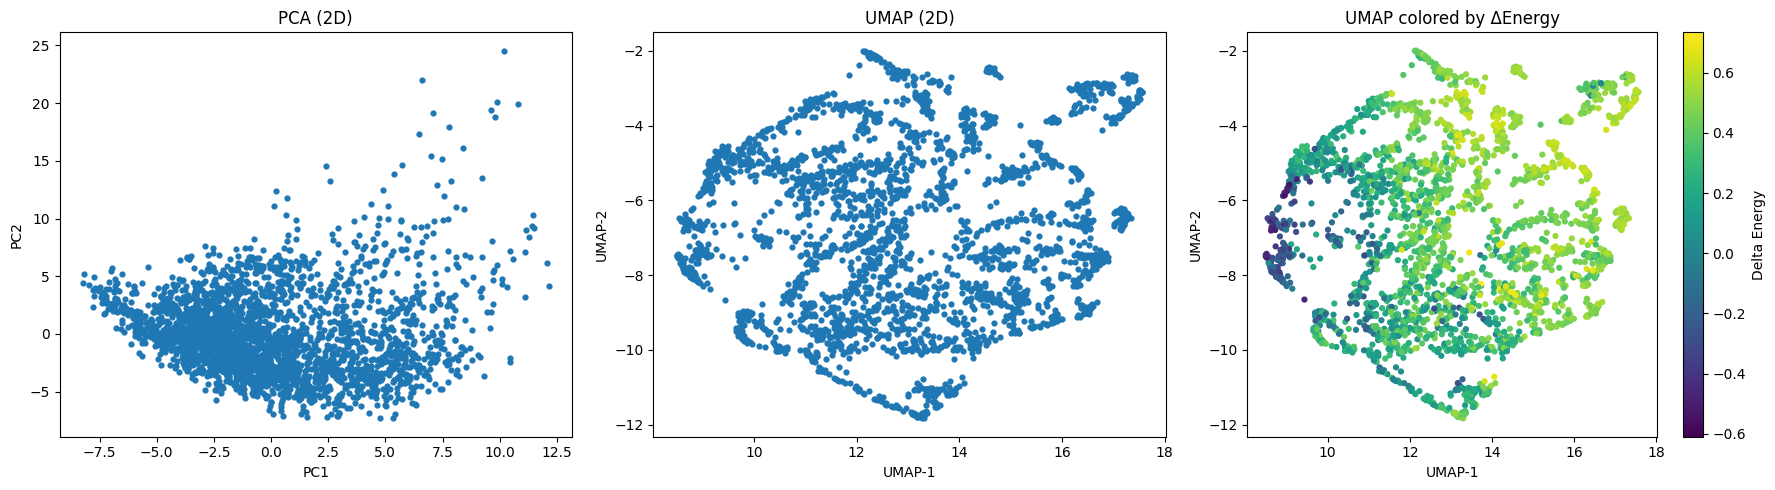

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df_phasef["pca_1"], df_phasef["pca_2"], s=12)
axes[0].set_title("PCA (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(df_phasef["umap_1"], df_phasef["umap_2"], s=12)
axes[1].set_title("UMAP (2D)")
axes[1].set_xlabel("UMAP-1")
axes[1].set_ylabel("UMAP-2")

scatter = axes[2].scatter(
    df_phasef["umap_1"],
    df_phasef["umap_2"],
    c=df_phasef["delta_energy"],
    s=12,
)
axes[2].set_title("UMAP colored by ΔEnergy")
axes[2].set_xlabel("UMAP-1")
axes[2].set_ylabel("UMAP-2")
plt.colorbar(scatter, ax=axes[2], label="Delta Energy")

plt.tight_layout()
plt.show()

In [6]:
# ------------------------------------------------------------
# Task 27 — Cluster learned embeddings
# ------------------------------------------------------------

def get_clustering_input(X_scaled: np.ndarray, config: PhaseFConfig) -> np.ndarray:
    n_components = min(config.pca_components_for_clustering, X_scaled.shape[1])
    pca = PCA(n_components=n_components, random_state=config.random_state)
    return pca.fit_transform(X_scaled)


def cluster_hdbscan(X_cluster: np.ndarray, config: PhaseFConfig) -> pd.DataFrame:
    if not HDBSCAN_AVAILABLE:
        raise ImportError("hdbscan is not installed.")

    model = hdbscan.HDBSCAN(
        min_cluster_size=config.hdbscan_min_cluster_size,
        min_samples=config.hdbscan_min_samples,
        prediction_data=True,
    )
    labels = model.fit_predict(X_cluster)

    if hasattr(model, "probabilities_"):
        confidence = model.probabilities_
    else:
        confidence = np.full(shape=len(labels), fill_value=np.nan)

    out = pd.DataFrame(
        {
            "cluster_method": "hdbscan",
            "cluster_label": labels.astype(int),
            "cluster_confidence": confidence.astype(float),
        }
    )
    return out


def cluster_kmeans(X_cluster: np.ndarray, config: PhaseFConfig) -> pd.DataFrame:
    model = KMeans(n_clusters=config.kmeans_k, n_init=20, random_state=config.random_state)
    labels = model.fit_predict(X_cluster)

    centers = model.cluster_centers_
    dists = np.linalg.norm(X_cluster - centers[labels], axis=1)
    confidence = 1.0 / (1.0 + dists)

    return pd.DataFrame(
        {
            "cluster_method": "kmeans",
            "cluster_label": labels.astype(int),
            "cluster_confidence": confidence.astype(float),
        }
    )


def cluster_gmm(X_cluster: np.ndarray, config: PhaseFConfig) -> pd.DataFrame:
    model = GaussianMixture(n_components=config.gmm_k, random_state=config.random_state)
    model.fit(X_cluster)
    labels = model.predict(X_cluster)
    probs = model.predict_proba(X_cluster).max(axis=1)

    return pd.DataFrame(
        {
            "cluster_method": "gmm",
            "cluster_label": labels.astype(int),
            "cluster_confidence": probs.astype(float),
        }
    )


def cluster_hierarchical(X_cluster: np.ndarray, config: PhaseFConfig) -> pd.DataFrame:
    model = AgglomerativeClustering(n_clusters=config.hierarchical_k)
    labels = model.fit_predict(X_cluster)

    return pd.DataFrame(
        {
            "cluster_method": "hierarchical",
            "cluster_label": labels.astype(int),
            "cluster_confidence": np.nan,
        }
    )


def run_clustering(df_2d: pd.DataFrame, X_scaled: np.ndarray, config: PhaseFConfig) -> tuple[pd.DataFrame, pd.DataFrame]:
    X_cluster = get_clustering_input(X_scaled, config)

    clustering_runs = []

    if HDBSCAN_AVAILABLE:
        clustering_runs.append(cluster_hdbscan(X_cluster, config))
    else:
        warnings.warn("HDBSCAN not available. HDBSCAN run skipped.")

    clustering_runs.append(cluster_kmeans(X_cluster, config))
    clustering_runs.append(cluster_gmm(X_cluster, config))
    clustering_runs.append(cluster_hierarchical(X_cluster, config))

    results = []
    metrics = []

    for run_df in clustering_runs:
        method = run_df["cluster_method"].iloc[0]
        tmp = df_2d.copy()
        tmp["cluster_method"] = method
        tmp["cluster_label"] = run_df["cluster_label"].values
        tmp["cluster_confidence"] = run_df["cluster_confidence"].values
        results.append(tmp)

        sil = safe_silhouette(X_cluster, run_df["cluster_label"].to_numpy())
        n_clusters = len(set(run_df["cluster_label"])) - (1 if -1 in set(run_df["cluster_label"]) else 0)
        noise_count = int((run_df["cluster_label"] == -1).sum())

        metrics.append(
            {
                "cluster_method": method,
                "n_clusters": n_clusters,
                "noise_points": noise_count,
                "silhouette_score": sil,
            }
        )

    df_clustered_all = pd.concat(results, ignore_index=True)
    df_metrics = pd.DataFrame(metrics).sort_values("silhouette_score", ascending=False, na_position="last")

    save_csv(df_clustered_all, config.outdir / "cluster_assignments_all_methods.csv")
    save_csv(df_metrics, config.outdir / "cluster_method_metrics.csv")

    return df_clustered_all, df_metrics


df_clustered_all, df_cluster_metrics = run_clustering(df_phasef, X_scaled, CONFIG)
df_cluster_metrics

,cluster_method,n_clusters,noise_points,silhouette_score
1,kmeans,6,0,0.106781
3,hierarchical,6,0,0.075795
2,gmm,6,0,0.067368
0,hdbscan,3,1486,0.013887


In [7]:
# Prefer HDBSCAN if available, otherwise best silhouette method
if HDBSCAN_AVAILABLE and (df_clustered_all["cluster_method"] == "hdbscan").any():
    PRIMARY_METHOD = "hdbscan"
else:
    PRIMARY_METHOD = df_cluster_metrics.iloc[0]["cluster_method"]

df_clustered = (
    df_clustered_all[df_clustered_all["cluster_method"] == PRIMARY_METHOD]
    .copy()
    .reset_index(drop=True)
)

save_csv(df_clustered, CONFIG.outdir / "cluster_assignments_primary.csv")

print("Primary clustering method:", PRIMARY_METHOD)
print(df_clustered["cluster_label"].value_counts(dropna=False).sort_index())

Primary clustering method: hdbscan
cluster_label
-1    1486
 0      41
 1      47
 2    1342
Name: count, dtype: int64


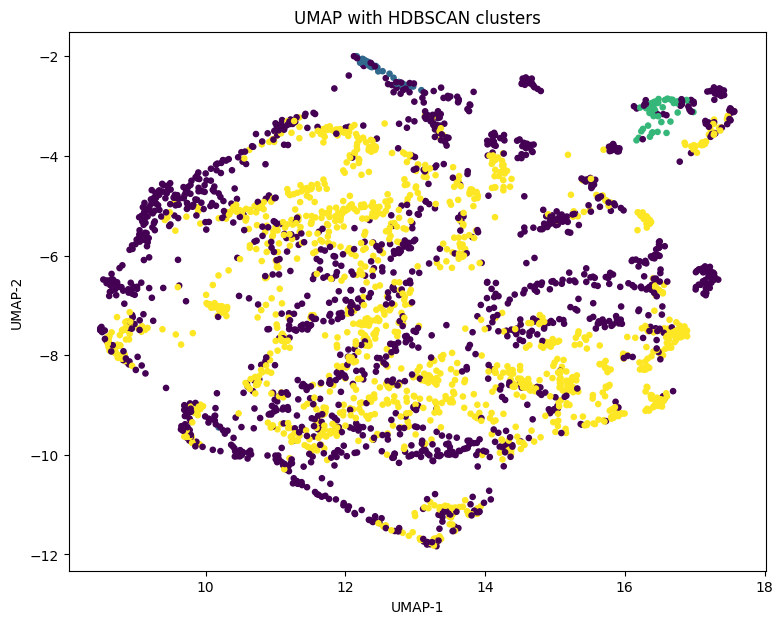

In [8]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    df_clustered["umap_1"],
    df_clustered["umap_2"],
    c=df_clustered["cluster_label"],
    s=14,
)
plt.title(f"UMAP with {PRIMARY_METHOD.upper()} clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [9]:
# ------------------------------------------------------------
# Task 28 — Identify structural motif families
# ------------------------------------------------------------

def summarize_clusters(df_clustered: pd.DataFrame, config: PhaseFConfig) -> pd.DataFrame:
    df = df_clustered.copy()

    valid = df[df["cluster_label"] != -1].copy()
    if valid.empty:
        raise ValueError("No non-noise clusters available for motif summary.")

    low_energy_threshold = valid["delta_energy"].quantile(config.low_energy_quantile)

    def proportion_low_energy(x: pd.Series) -> float:
        return float((x <= low_energy_threshold).mean())

    agg = {
        "structure_id": "count",
        "energy": ["mean", "std", "min", "max"],
        "delta_energy": ["mean", "std", "min", "max", proportion_low_energy],
        "lower_rotation": ["mean", "std"],
        "displacement": ["mean", "std"],
        "upper_rotation": ["mean", "std"],
        "cluster_confidence": ["mean"],
    }

    optional_feature_cols = [
        "centroid_separation",
        "com_separation",
        "interlayer_dist_mean",
        "interlayer_dist_min",
        "interlayer_dist_max",
        "lower_nn_mean",
        "upper_nn_mean",
    ]
    for col in optional_feature_cols:
        if col in valid.columns:
            agg[col] = ["mean", "std"]

    summary = valid.groupby("cluster_label").agg(agg)
    summary.columns = [
        "_".join([str(part) for part in col if str(part)]).replace("<lambda_0>", "low_energy_proportion")
        for col in summary.columns.to_flat_index()
    ]
    summary = summary.reset_index().rename(columns={"structure_id_count": "cluster_size"})
    summary = summary.sort_values("cluster_size", ascending=False).reset_index(drop=True)

    summary = assign_motif_names(summary)

    save_csv(summary, config.outdir / "motif_cluster_summary.csv")
    return summary


df_motif_summary = summarize_clusters(df_clustered, CONFIG)
df_motif_summary.head(10)

,cluster_label,cluster_size,energy_mean,energy_std,energy_min,energy_max,delta_energy_mean,delta_energy_std,delta_energy_min,delta_energy_max,...,interlayer_dist_mean_std,interlayer_dist_min_mean,interlayer_dist_min_std,interlayer_dist_max_mean,interlayer_dist_max_std,lower_nn_mean_mean,lower_nn_mean_std,upper_nn_mean_mean,upper_nn_mean_std,motif_name
0,2,1342,-936.312050,0.229416,-937.059387,-935.906006,0.327750,0.229416,-0.41960,0.73380,...,0.611989,2.404544,0.472862,21.350524,0.881663,1.135708,0.005885,1.137714,0.019263,shifted loose twisted stacking (stable)
1,1,47,-936.209619,0.123761,-936.639771,-936.067322,0.430182,0.123769,0.00000,0.57250,...,0.234965,3.192279,0.334418,20.790855,0.594841,1.135018,0.000158,1.137061,0.018216,shifted compact ordered stacking (unstable)
2,0,41,-936.224338,0.087376,-936.386414,-936.045593,0.415461,0.087375,0.25337,0.59419,...,0.221665,2.530971,0.278072,20.918293,0.408780,1.135111,0.000190,1.139560,0.018207,aligned loose ordered stacking (moderate)


In [10]:
display_cols = [
    "cluster_label",
    "motif_name",
    "cluster_size",
    "delta_energy_mean",
    "delta_energy_std",
    "delta_energy_low_energy_proportion",
    "displacement_mean",
    "lower_rotation_mean",
    "upper_rotation_mean",
]

display_cols = [c for c in display_cols if c in df_motif_summary.columns]
df_motif_summary[display_cols]

,cluster_label,motif_name,cluster_size,delta_energy_mean,delta_energy_std,displacement_mean,lower_rotation_mean,upper_rotation_mean
0,2,shifted loose twisted stacking (stable),1342,0.327750,0.229416,4.419970,177.377049,165.454545
1,1,shifted compact ordered stacking (unstable),47,0.430182,0.123769,4.212766,240.000000,228.936170
2,0,aligned loose ordered stacking (moderate),41,0.415461,0.087375,4.126829,131.707317,149.268293


In [11]:
# ------------------------------------------------------------
# Task 29 — Select representative structures per motif
# ------------------------------------------------------------

def select_cluster_representatives(
    df_clustered: pd.DataFrame,
    embedding_cols: list[str],
    config: PhaseFConfig,
) -> pd.DataFrame:
    rows = []

    valid = df_clustered[df_clustered["cluster_label"] != -1].copy()

    for cluster_id, group in valid.groupby("cluster_label"):
        group = group.copy().reset_index(drop=True)
        X_group = group[embedding_cols].to_numpy(dtype=float)

        centroid = X_group.mean(axis=0)
        dists = np.linalg.norm(X_group - centroid, axis=1)

        idx_centroid_nearest = int(np.argmin(dists))
        idx_most_unusual = int(np.argmax(dists))
        idx_lowest_energy = int(group["delta_energy"].idxmin() - group.index.min())

        # "Most typical" = high confidence if available, else centroid-nearest
        if "cluster_confidence" in group.columns and group["cluster_confidence"].notna().any():
            idx_typical = int(group["cluster_confidence"].fillna(-1).to_numpy().argmax())
        else:
            idx_typical = idx_centroid_nearest

        selected = {
            "cluster_label": cluster_id,
            "centroid_nearest_structure_id": group.iloc[idx_centroid_nearest]["structure_id"],
            "centroid_nearest_relative_cif_path": group.iloc[idx_centroid_nearest].get("relative_cif_path"),
            "lowest_energy_structure_id": group.iloc[idx_lowest_energy]["structure_id"],
            "lowest_energy_relative_cif_path": group.iloc[idx_lowest_energy].get("relative_cif_path"),
            "most_typical_structure_id": group.iloc[idx_typical]["structure_id"],
            "most_typical_relative_cif_path": group.iloc[idx_typical].get("relative_cif_path"),
            "most_unusual_structure_id": group.iloc[idx_most_unusual]["structure_id"],
            "most_unusual_relative_cif_path": group.iloc[idx_most_unusual].get("relative_cif_path"),
            "cluster_size": len(group),
        }

        rows.append(selected)

    reps = pd.DataFrame(rows).sort_values("cluster_label").reset_index(drop=True)

    if (CONFIG.outdir / "motif_cluster_summary.csv").exists():
        motif_summary = pd.read_csv(CONFIG.outdir / "motif_cluster_summary.csv")
        reps = reps.merge(
            motif_summary[["cluster_label", "motif_name"]],
            on="cluster_label",
            how="left",
        )

    save_csv(reps, config.outdir / "motif_representatives.csv")
    return reps


df_representatives = select_cluster_representatives(df_clustered, EMBEDDING_COLS, CONFIG)
df_representatives

,cluster_label,centroid_nearest_structure_id,centroid_nearest_relative_cif_path,lowest_energy_structure_id,lowest_energy_relative_cif_path,most_typical_structure_id,most_typical_relative_cif_path,most_unusual_structure_id,most_unusual_relative_cif_path,cluster_size,motif_name
0,0,L120_D6_U280,r120/t6.0/t6.0_280.cif,L140_D6_U80,r140/t6.0/t6.0_80.cif,L120_D0_U280,r120/t0/t0_280.cif,L120_D4.8_U80,r120/t4.8/t4.8_80.cif,41,aligned loose ordered stacking (moderate)
1,1,L240_D0_U260,r240/t0/t0_260.cif,L240_D8.4_U260,r240/t8.4/t8.4_260.cif,L240_D0_U100,r240/t0/t0_100.cif,L240_D3.6_U240,r240/t3.6/t3.6_240.cif,47,shifted compact ordered stacking (unstable)
2,2,L340_D1.2_U220,r340/t1.2/t1.2_220.cif,L220_D7.2_U320,r220/t7.2/t7.2_320.cif,L0_D0_U180,r0/t0/t0_180.cif,L220_D7.2_U300,r220/t7.2/t7.2_300.cif,1342,shifted loose twisted stacking (stable)


In [12]:
def make_long_gallery_table(df_representatives: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for _, row in df_representatives.iterrows():
        cluster_label = row["cluster_label"]
        motif_name = row.get("motif_name")

        mapping = {
            "centroid_nearest": (
                row["centroid_nearest_structure_id"],
                row["centroid_nearest_relative_cif_path"],
            ),
            "lowest_energy": (
                row["lowest_energy_structure_id"],
                row["lowest_energy_relative_cif_path"],
            ),
            "most_typical": (
                row["most_typical_structure_id"],
                row["most_typical_relative_cif_path"],
            ),
            "most_unusual": (
                row["most_unusual_structure_id"],
                row["most_unusual_relative_cif_path"],
            ),
        }

        for rep_type, (sid, path) in mapping.items():
            rows.append(
                {
                    "cluster_label": cluster_label,
                    "motif_name": motif_name,
                    "representative_type": rep_type,
                    "structure_id": sid,
                    "relative_cif_path": path,
                }
            )

    return pd.DataFrame(rows)


df_gallery = make_long_gallery_table(df_representatives)
save_csv(df_gallery, CONFIG.outdir / "motif_gallery_long.csv")
df_gallery.head(12)

,cluster_label,motif_name,representative_type,structure_id,relative_cif_path
0,0,aligned loose ordered stacking (moderate),centroid_nearest,L120_D6_U280,r120/t6.0/t6.0_280.cif
1,0,aligned loose ordered stacking (moderate),lowest_energy,L140_D6_U80,r140/t6.0/t6.0_80.cif
2,0,aligned loose ordered stacking (moderate),most_typical,L120_D0_U280,r120/t0/t0_280.cif
3,0,aligned loose ordered stacking (moderate),most_unusual,L120_D4.8_U80,r120/t4.8/t4.8_80.cif
4,1,shifted compact ordered stacking (unstable),centroid_nearest,L240_D0_U260,r240/t0/t0_260.cif
5,1,shifted compact ordered stacking (unstable),lowest_energy,L240_D8.4_U260,r240/t8.4/t8.4_260.cif
6,1,shifted compact ordered stacking (unstable),most_typical,L240_D0_U100,r240/t0/t0_100.cif
7,1,shifted compact ordered stacking (unstable),most_unusual,L240_D3.6_U240,r240/t3.6/t3.6_240.cif
8,2,shifted loose twisted stacking (stable),centroid_nearest,L340_D1.2_U220,r340/t1.2/t1.2_220.cif
9,2,shifted loose twisted stacking (stable),lowest_energy,L220_D7.2_U320,r220/t7.2/t7.2_320.cif


In [13]:
# ------------------------------------------------------------
# Task 30 — Analyze motif stability patterns
# ------------------------------------------------------------

def build_motif_stability_table(df_clustered: pd.DataFrame, df_motif_summary: pd.DataFrame, config: PhaseFConfig) -> pd.DataFrame:
    valid = df_clustered[df_clustered["cluster_label"] != -1].copy()

    low_energy_threshold = valid["delta_energy"].quantile(config.low_energy_quantile)

    stability = (
        valid.groupby("cluster_label")
        .agg(
            cluster_size=("structure_id", "count"),
            energy_mean=("energy", "mean"),
            energy_std=("energy", "std"),
            delta_energy_mean=("delta_energy", "mean"),
            delta_energy_std=("delta_energy", "std"),
            delta_energy_min=("delta_energy", "min"),
            delta_energy_max=("delta_energy", "max"),
            low_energy_count=("delta_energy", lambda x: int((x <= low_energy_threshold).sum())),
            low_energy_proportion=("delta_energy", lambda x: float((x <= low_energy_threshold).mean())),
        )
        .reset_index()
    )

    stability["stability_rank"] = stability["delta_energy_mean"].rank(method="dense", ascending=True).astype(int)

    stability = stability.merge(
        df_motif_summary[["cluster_label", "motif_name"]],
        on="cluster_label",
        how="left",
    ).sort_values(["stability_rank", "cluster_label"]).reset_index(drop=True)

    save_csv(stability, config.outdir / "motif_stability_summary.csv")
    return stability


df_stability = build_motif_stability_table(df_clustered, df_motif_summary, CONFIG)
df_stability

,cluster_label,cluster_size,energy_mean,energy_std,delta_energy_mean,delta_energy_std,delta_energy_min,delta_energy_max,low_energy_count,low_energy_proportion,stability_rank,motif_name
0,2,1342,-936.312050,0.229416,0.327750,0.229416,-0.41960,0.73380,143,0.106557,1,shifted loose twisted stacking (stable)
1,0,41,-936.224338,0.087376,0.415461,0.087375,0.25337,0.59419,0,0.000000,2,aligned loose ordered stacking (moderate)
2,1,47,-936.209619,0.123761,0.430182,0.123769,0.00000,0.57250,3,0.063830,3,shifted compact ordered stacking (unstable)


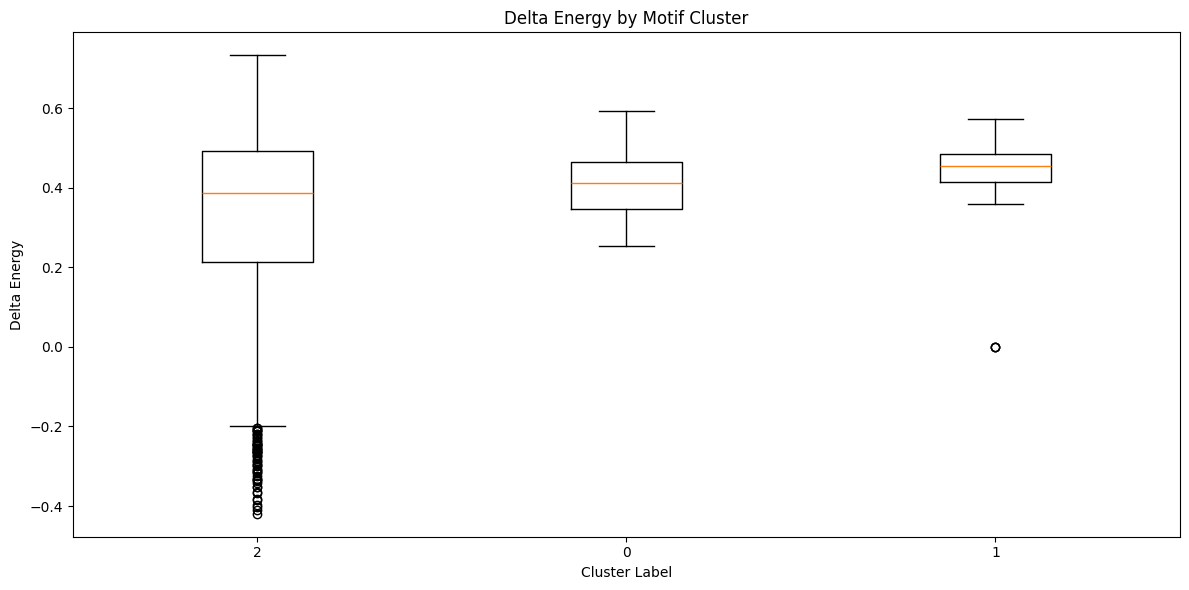

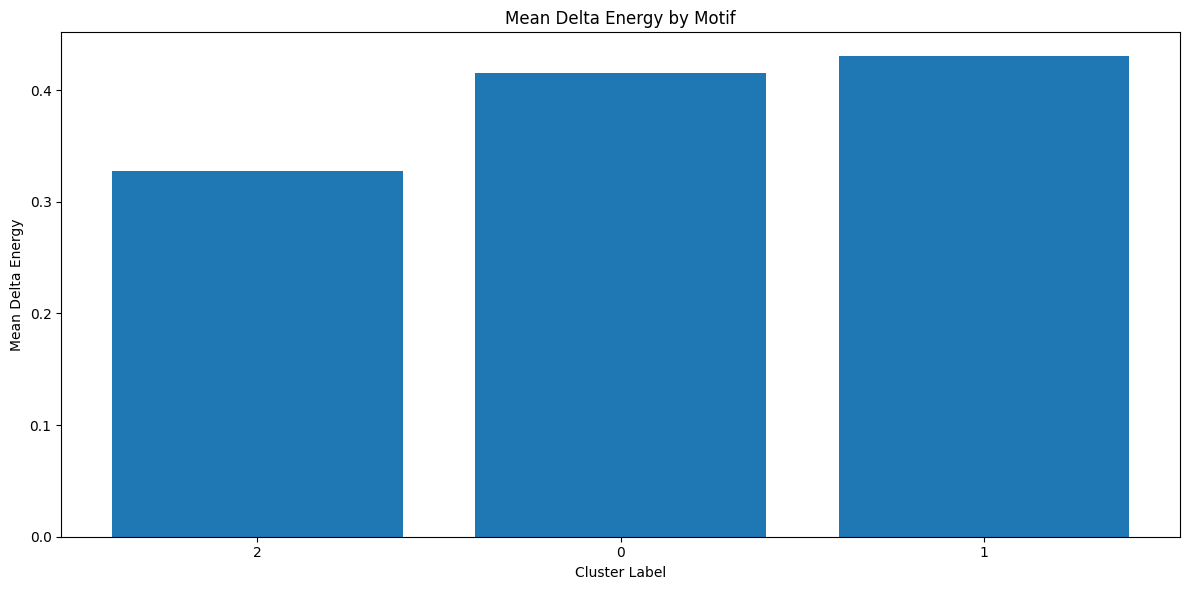

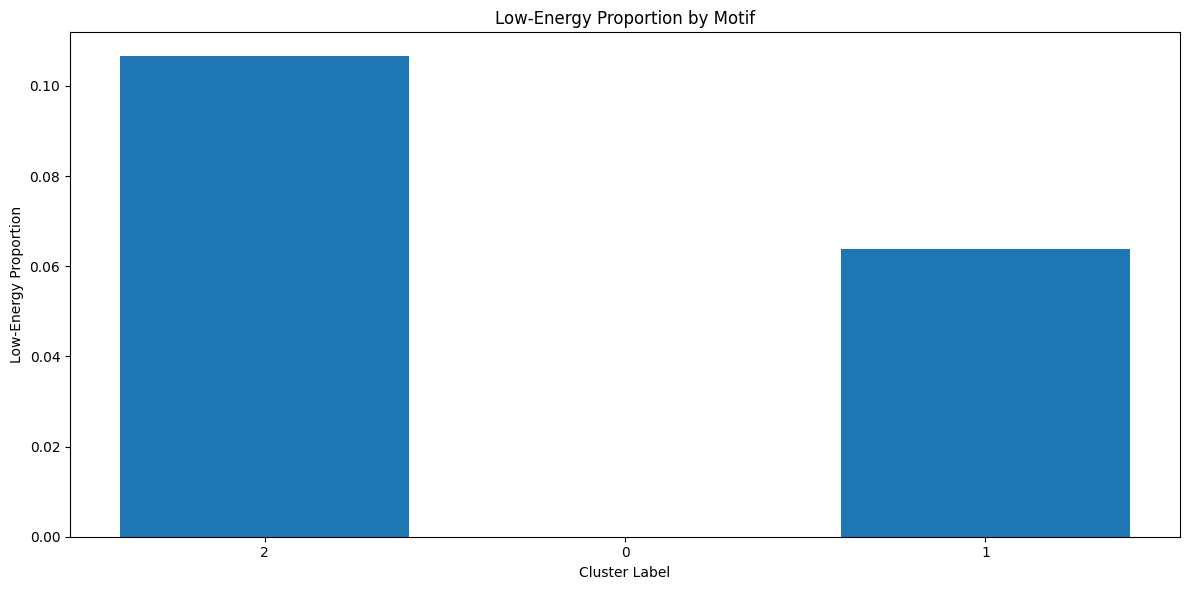

In [15]:
valid = df_clustered[df_clustered["cluster_label"] != -1].copy()
ordered_clusters = (
    df_stability.sort_values("delta_energy_mean", ascending=True)["cluster_label"].tolist()
)

plt.figure(figsize=(12, 6))
data = [
    valid.loc[valid["cluster_label"] == c, "delta_energy"].dropna().to_numpy()
    for c in ordered_clusters
]
plt.boxplot(data, tick_labels=ordered_clusters)
plt.title("Delta Energy by Motif Cluster")
plt.xlabel("Cluster Label")
plt.ylabel("Delta Energy")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
x = np.arange(len(df_stability))
plt.bar(x, df_stability["delta_energy_mean"])
plt.xticks(x, df_stability["cluster_label"])
plt.title("Mean Delta Energy by Motif")
plt.xlabel("Cluster Label")
plt.ylabel("Mean Delta Energy")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
x = np.arange(len(df_stability))
plt.bar(x, df_stability["low_energy_proportion"])
plt.xticks(x, df_stability["cluster_label"])
plt.title("Low-Energy Proportion by Motif")
plt.xlabel("Cluster Label")
plt.ylabel("Low-Energy Proportion")
plt.tight_layout()
plt.show()

In [16]:
final_cols = [
    "structure_id",
    "relative_cif_path",
    "lower_rotation",
    "displacement",
    "upper_rotation",
    "energy",
    "delta_energy",
    "pca_1",
    "pca_2",
    "umap_1",
    "umap_2",
    "tsne_1",
    "tsne_2",
    "cluster_method",
    "cluster_label",
    "cluster_confidence",
]

final_cols = [c for c in final_cols if c in df_clustered.columns]

df_final_phasef = df_clustered[final_cols].merge(
    df_motif_summary[["cluster_label", "motif_name"]],
    on="cluster_label",
    how="left",
)

save_csv(df_final_phasef, CONFIG.outdir / "phase_f_master_results.csv")
print("Saved:", CONFIG.outdir / "phase_f_master_results.csv")
df_final_phasef.head()

Saved: D:\masters_project\outputs\motif_discovery\phase_f_master_results.csv


,structure_id,relative_cif_path,lower_rotation,displacement,upper_rotation,energy,delta_energy,pca_1,pca_2,umap_1,umap_2,tsne_1,tsne_2,cluster_method,cluster_label,cluster_confidence,motif_name
0,L0_D0_U0,r0/t0/t0_0.cif,0.0,0.0,0.0,-936.509583,0.13021,2.698780,-2.145542,13.232353,-9.693111,16.256012,18.173557,hdbscan,2,0.878092,shifted loose twisted stacking (stable)
1,L0_D0_U100,r0/t0/t0_100.cif,0.0,0.0,100.0,-936.201538,0.43826,2.613275,-1.342387,11.643525,-9.549086,33.514286,17.762970,hdbscan,2,0.898457,shifted loose twisted stacking (stable)
2,L0_D0_U120,r0/t0/t0_120.cif,0.0,0.0,120.0,-936.242065,0.39772,4.023746,-2.281294,11.926418,-9.504131,28.649391,20.207617,hdbscan,2,0.945606,shifted loose twisted stacking (stable)
3,L0_D0_U140,r0/t0/t0_140.cif,0.0,0.0,140.0,-936.156982,0.48284,2.047858,-4.149553,12.978029,-9.060637,15.751867,13.407825,hdbscan,-1,0.000000,NaN
4,L0_D0_U160,r0/t0/t0_160.cif,0.0,0.0,160.0,-936.079590,0.56023,-0.147532,-2.799350,14.367900,-8.496241,-14.410838,7.230876,hdbscan,2,0.951519,shifted loose twisted stacking (stable)


In [17]:
output_files = sorted(CONFIG.outdir.glob("*"))
for file in output_files:
    print(file.name)

cluster_assignments_all_methods.csv
cluster_assignments_primary.csv
cluster_method_metrics.csv
embedding_2d.csv
motif_cluster_summary.csv
motif_gallery_long.csv
motif_representatives.csv
motif_stability_summary.csv
phase_f_master_results.csv
